#### Binomial graphing script

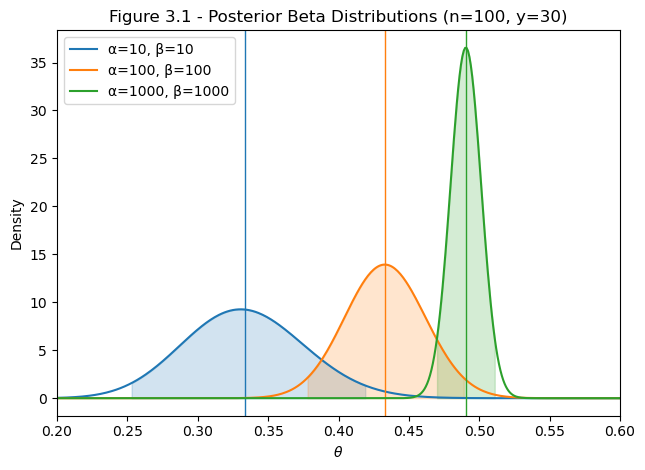

\begin{tabular}{lrrr}
\toprule
Prior $(\alpha,\beta)$ & Posterior mean & 95\% CI lower & 95\% CI upper \\
\midrule
10,10 & 0.333 & 0.252 & 0.420 \\
100,100 & 0.433 & 0.378 & 0.490 \\
1000,1000 & 0.490 & 0.469 & 0.512 \\
\bottomrule
\end{tabular}



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
import pandas as pd

# ---------- configurable inputs ----------
n = 100           # number of Bernoulli trials
y = 30            # observed successes
priors = [(10, 10), (100, 100), (1000, 1000)]   # (alpha, beta) prior pairs
cred_mass = 0.95  # central posterior interval mass
# -----------------------------------------

theta = np.linspace(0, 1, 1001)

def posterior_params(alpha_prior, beta_prior, n, y):
    """Return posterior alpha, beta for Beta–Binomial model."""
    return alpha_prior + y, beta_prior + (n - y)

def posterior_summary(alpha_post, beta_post, cred_mass=0.95):
    mean = alpha_post / (alpha_post + beta_post)
    lower = beta.ppf((1 - cred_mass) / 2, alpha_post, beta_post)
    upper = beta.ppf(1 - (1 - cred_mass) / 2, alpha_post, beta_post)
    return mean, lower, upper

summaries = []

plt.figure()
for alpha_prior, beta_prior in priors:
    alpha_post, beta_post = posterior_params(alpha_prior, beta_prior, n, y)
    pdf_vals = beta.pdf(theta, alpha_post, beta_post)
    
    # Plot posterior density
    line, = plt.plot(theta, pdf_vals, label=f"α={alpha_prior}, β={beta_prior}")
    col = line.get_color()
    
    # Compute summary statistics
    mean, lower, upper = posterior_summary(alpha_post, beta_post, cred_mass)
    summaries.append({
        "Prior $(\\alpha,\\beta)$": f"{alpha_prior},{beta_prior}",
        "Posterior mean": mean,
        "95\\% CI lower": lower,
        "95\\% CI upper": upper
    })
    
    # Shade the 95% central posterior interval
    plt.fill_between(theta, 0, pdf_vals,
                     where=(theta >= lower) & (theta <= upper),
                     color=col, alpha=0.2)
    # Draw vertical line at posterior mean
    plt.axvline(mean,  color=col, linestyle="-",  linewidth=1)

plt.title(f"Figure 3.1 - Posterior Beta Distributions (n={n}, y={y})")
plt.xlabel("$\\theta$")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.xlim(0.2, 0.6)
plt.show()

# Produce LaTeX‑formatted summary table
summary_df = pd.DataFrame(summaries)
latex_table = summary_df.to_latex(index=False, float_format="%.3f", escape=False)
print(latex_table)
